### Modèles de regressions avec de la régularisation

In [8]:
import sys
sys.path.append('..')

from utils.fonctions import load_parquet_data, load_pickle
from src.artifacts.data_processing import Nettoyage
from src.artifacts.encoders import LogTransformer

import sklearn
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import numpy as np, pandas as pd

sklearn.set_config(transform_output='pandas')
import matplotlib.pyplot as plt

import category_encoders as ce


def run_nettoyage(data, encoding_pipeline, nettoyage_pipeline: Nettoyage, methode='entropy', downcast_num_cols=True) -> Nettoyage:
    """
    data : pd.DataFrame, dataframe a numeriser
    encoding_pipeline : pipeline de numerisation des variables categorielles
    nettoyage_pipeline : pipeline de nettoyage des variables numeriques (importer depuis src.artifacts.data_processing)
    methode : Methode de nettoyage a utiliser : 'entropy' ou 'target_correlation'
    downcast_num_cols : bool, si True, downcast les colonnes numeriques
    """
    
    def downcast_numeric_cols(data):
        # int32 range = 2**32/2 à gauche et à droite de 0
        for c in data.columns:
            if data[c].dtype == 'int64':
                data[c] = data[c].astype('int32')
            elif data[c].dtype == 'float64':
                data[c] = data[c].astype('float32')
        return data
    
    def numerize(data, encoding_pipeline, downcast_num_cols):
        encoding_pipeline.set_output(transform='pandas')
        data = encoding_pipeline.fit_transform(data)
        if downcast_num_cols:
            print(f"-> downcast des colonnes numeriques (64->32)")
            data = downcast_numeric_cols(data)
        return data
    
    assert isinstance(data, pd.DataFrame), "data doit être un DataFrame"
    if 'arrondissement' not in data.columns: data['arrondissement'] = 1
    data = numerize(data, encoding_pipeline, downcast_num_cols)
    pipeline_ins = nettoyage_pipeline(data)
    if methode == 'entropy':
        pipeline_ins.run(use_entropy_selection=True)
    elif methode == 'target_correlation':
        pipeline_ins.run(use_target_correlation_selection=True)
    else:
        raise ValueError("La méthode doit être 'entropy' ou 'target_correlation'")
    pipeline_ins.df['arrondissement'] = pipeline_ins.df['arrondissement'].astype('int32')
    return pipeline_ins

In [3]:
categ_encoders = load_pickle("../ressources/encoders_fitted/categorical_encoders.pkl")
df_raw = load_parquet_data('../ressources/data/2_intermediary/enedis_ban_ademe_extract_PARIS_2022.parquet')

pipeline = run_nettoyage(df_raw, categ_encoders, Nettoyage, methode='entropy', downcast_num_cols=True)

Loading parquet data from : ../ressources/data/2_intermediary/enedis_ban_ademe_extract_PARIS_2022.parquet..
-> downcast des colonnes numeriques (64->32)
-> Delete cols mano..
-> Delete NaN cols..
Le dataframe contient initialement 251 colonnes et 464576 lignes.
Start processing : columns identification..
Il y a 76 colonnes vides à au moins, 90.0%, 63 colonnes avec une entropie de 0 ou 1 et 13 colonnes inutiles
Start processing : columns deleting ...
Il reste 138 colonnes et 370056 lignes.
-> Start object columns auto casting..
End casting
-> Fill pd.NA for float dtypes..
Done fillnan !
Les colonnes suivantes ont une corrélation supérieure à 0.9 : ['emission_ges_5_usages_energie_ndeg1_ademe', 'deperditions_ponts_thermiques_ademe', 'cout_total_5_usages_ademe', 'conso_chauffage_depensier_e_finale_ademe', 'deperditions_renouvellement_air_ademe', 'emission_ges_chauffage_ademe', 'conso_auxiliaires_e_finale_ademe', 'conso_5_usages_e_primaire_ademe', 'cout_eclairage_ademe', 'conso_refroidissem

In [4]:
df = pipeline.df
df.sort_index(axis=1, inplace=True)
TARGET_COL = "conso_kwh_m2"
# del pipeline

In [5]:
_ = list(filter(lambda c: 'ndeg' not in c, df.columns))

use_cols = [
       # 'annee_construction_ademe', 
       'apports_internes_saison_froid_ademe',
       'apports_solaires_saison_chauffe_ademe',
       'apports_solaires_saison_froid_ademe', 
       'arrondissement',
       'besoin_chauffage_ademe', 
       'besoin_refroidissement_ademe',
       'besoin_refroidissement_depensier_ademe', 
       'categorie_enr_ademe_0',
       'classe_inertie_batiment_ademe',
       'configuration_installation_chauffage_ndeg1_ademe_0',
       'configuration_installation_ecs_ademe_0',
       'conso_5_usages_e_finale_energie_ndeg2_ademe',
       'conso_5_usages_m2_e_finale_ademe',
       'conso_5_usages_par_m2_e_primaire_ademe',
       'conso_auxiliaires_e_primaire_ademe',
       'conso_chauffage_e_primaire_ademe',
       'conso_e_finale_depensier_installation_ecs_ademe',
       'conso_ecs_depensier_e_primaire_ademe',
       'conso_ecs_e_finale_energie_ndeg2_ademe', 
       'conso_kwh_m2',
       'conso_refroidissement_e_finale_ademe',
       'consommation_annuelle_totale_de_l_adresse_mwh_enedis_with_ban',
       # 'coordonnee_cartographique_x_ban_ademe',
       # 'coordonnee_cartographique_y_ban_ademe', 
       'cout_auxiliaires_ademe',
       'cout_chauffage_energie_ndeg2_ademe', 
       'cout_refroidissement_ademe',
       'cout_refroidissement_depensier_ademe',
       'deperditions_baies_vitrees_ademe', 
       'deperditions_planchers_bas_ademe',
       'deperditions_planchers_hauts_ademe', 
       'deperditions_portes_ademe',
       'emission_ges_5_usages_energie_ndeg2_ademe',
       'emission_ges_5_usages_par_m2_ademe',
       'emission_ges_chauffage_energie_ndeg2_ademe',
       'emission_ges_ecs_energie_ndeg2_ademe',
       'emission_ges_refroidissement_ademe',
       'emission_ges_refroidissement_depensier_ademe', 
       'etiquette_dpe_ademe',
       'etiquette_ges_ademe', 
       'hauteur_sous_plafond_ademe',
       # 'lat_enedis_with_ban', 
       # 'lon_enedis_with_ban',
       'methode_application_dpe_ademe_0', 
       'ndeg_etage_appartement_ademe',
       'nombre_appartement_ademe',
       'nombre_logements_desservis_par_installation_ecs_ademe',
       'nombre_niveau_immeuble_ademe', 
       'nombre_niveau_logement_ademe',
       'periode_construction_ademe', 
       'qualite_isolation_enveloppe_ademe',
       'qualite_isolation_menuiseries_ademe', 
       'qualite_isolation_murs_ademe',
       'qualite_isolation_plancher_bas_ademe',
       'qualite_isolation_plancher_haut_comble_perdu_ademe',
       'qualite_isolation_plancher_haut_toit_terrase_ademe', 
       # 'score_ban_ademe',
       'surface_habitable_immeuble_ademe', 
       'surface_habitable_logement_ademe',
       'type_batiment_ademe_0',
       # 'type_emetteur_installation_chauffage_ndeg1_ademe_0',
       'type_enedis_with_ban_0', 
       'type_energie_generateur_ecs_ndeg1_ademe_0',
       'type_energie_generateur_ndeg1_installation_ndeg1_ademe_0',
       'type_energie_ndeg1_ademe_0', 
       'type_energie_ndeg2_ademe_0',
       'type_energie_principale_chauffage_ademe_0',
       'type_energie_principale_ecs_ademe_0',
       'type_generateur_ecs_ndeg1_ademe_0',
       'type_generateur_ndeg1_installation_ndeg1_ademe_0',
       'type_installation_chauffage_ademe_0',
       'type_installation_chauffage_ndeg1_ademe_0',
       'type_installation_ecs_ademe_0',
       'type_installation_ecs_general_ademe_0', 
       'ubat_w_m2_k_ademe',
       'usage_generateur_ecs_ndeg1_ademe_0',
       'usage_generateur_ndeg1_installation_ndeg1_ademe_0',
       # 'version_dpe_ademe', 
       'volume_stockage_generateur_ecs_ndeg1_ademe']

df = df[use_cols]
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
cols_to_scale = list(set(X_train.columns))

def make_model_with_one_hot_encoder_and_log_scaler(model, cols_to_scale, cols_to_encode):
    return Pipeline([
        (
            're_encoding', 
            ColumnTransformer(
                [
                    ('s_scaler', StandardScaler(), cols_to_scale),
                    ('one_hot_encoder', ce.OneHotEncoder(cols=cols_to_encode), cols_to_encode),
                ], 
                remainder='passthrough', 
                verbose_feature_names_out=False)
        ),
        ('model', model)
    ])

def make_model_with_count_encoder_and_standard_scaler(model, cols_to_scale, cols_to_encode):
    return Pipeline([
        (
            're_encoding', 
            ColumnTransformer(
                [
                    ('s_scaler', StandardScaler(), cols_to_scale),
                    ('count_encoder', ce.CountEncoder(cols=cols_to_encode, min_group_size=1_000), cols_to_encode),
                ], 
                remainder='passthrough', 
                verbose_feature_names_out=False)
        ),
        ('model', model)
    ])

def make_model_with_one_hot_encoder_and_standard_scaler(model, cols_to_scale, cols_to_encode):
    return Pipeline([
        (
            're_encoding', 
            ColumnTransformer(
                [
                    ('s_scaler', StandardScaler(), cols_to_scale),
                    ('one_hot_encoder', ce.OneHotEncoder(cols=cols_to_encode), cols_to_encode),
                ], 
                remainder='passthrough', 
                verbose_feature_names_out=False)
        ),
        ('model', model)
    ])

In [10]:
ordinal_features = categ_encoders.named_transformers_['ordinal_encoding'].get_feature_names_out()
label_features = categ_encoders.named_transformers_['label_encoding'].get_feature_names_out()
categ_features = ordinal_features.tolist() + label_features.tolist()

to_onehot_encode = list(filter(lambda c: c in categ_features, X.columns))
to_scale = list(filter(lambda c: c not in to_onehot_encode, X.columns))

### Lasso and Ridge Regressions

Lasso (Least Absolute Shrinkage and Selection Operator) and Ridge regression are regularization techniques used to prevent overfitting in linear regression models by adding a penalty term to the loss function.

#### The Alpha Parameter
- The **alpha** parameter controls the strength of the regularization:
    - A higher alpha increases the penalty, leading to more shrinkage of coefficients.
    - A lower alpha reduces the penalty, making the model closer to standard linear regression.
- Choosing the right alpha is crucial and is often done using cross-validation.

In [ ]:
# grid for Rid // ridge uses L2 constraint for regularization
ridge_param_grid = {'alpha': np.linspace(0.001, 5, 20)}

# grid for Lasso
lasso_param_grid = {'alpha': np.logspace(0.001, 10, 20)}

def evaluate_model(model, X_train, X_test, y_train, y_test):
    # fonction pour calculer les métriques
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mape = mean_absolute_percentage_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    return model, round(rmse, 3), round(mape, 3), round(r2, 3)

Ridge - RMSE: 44.728 MAPE: 0.488 R2: 0.527


#### recherche d'hyperparametres

In [ ]:
global opti_alphas
opti_alphas = {}

def make_model_opti_alphas_with_threads(model, alpha, X_train, y_train, X_test, y_test):
    pass

In [ ]:
import threading

alphas = np.linspace(0.001, 10, 5)
rmse_scores = []
mape_scores = []
r2_scores = []

for make_model, alpha in alphas:
    
    ridge_v1 = make_model_with_one_hot_encoder_and_standard_scaler(
        model = Ridge(alpha=alpha), 
        cols_to_scale=to_scale, 
        cols_to_encode=to_onehot_encode
        )
    ridge_v1.fit(X_train, y_train)
    y_pred = ridge_v1.predict(X_test)

    rmse_scores.append(round(np.sqrt(mean_squared_error(y_test, y_pred)), 3))
    mape_scores.append(round(mean_absolute_percentage_error(y_test, y_pred), 3))
    r2_scores.append(round(r2_score(y_test, y_pred), 3))

# plot the scores
fig, axes = plt.subplots(1, 3, figsize=(30, 8))

axes[0].plot(alphas, rmse_scores, marker='o', label='RMSE')
axes[0].set_title('RMSE - Alpha')
axes[0].set_xlabel('Alpha')
axes[0].set_ylabel('RMSE')
axes[0].grid()
axes[0].legend()

axes[1].plot(alphas, mape_scores, marker='o', label='MAPE', color='orange')
axes[1].set_title('MAPE - Alpha')
axes[1].set_xlabel('Alpha')
axes[1].set_ylabel('MAPE')
axes[1].grid()
axes[1].legend()

axes[2].plot(alphas, r2_scores, marker='o', label='R2', color='green')
axes[2].set_title('R2 - Alpha')
axes[2].set_xlabel('Alpha')
axes[2].set_ylabel('R2')
axes[2].grid()
axes[2].legend()
fig.suptitle('Regression Ridge - Recherche d\'hyperparamètres', fontsize=16)
plt.tight_layout()
plt.show()

#### evaluation d'un seul modèle pour comparer avec la regression simple
*puisque alpha n'a pas d'incidence réelle sur la qualitée de la regression, on va juste choisir un alpha au pif pour lasso et ridge. Ce faisant, on aura un modèle pour chacun qu'on pourra alors comparer à la regression simple.*

In [ ]:
# évaluer modèles
model_pipeline = make_model_with_one_hot_encoder_and_standard_scaler(Ridge(alpha=5), to_scale, to_onehot_encode)
ridge_results = evaluate_model(model_pipeline, X_train, X_test, y_train, y_test)

print("Ridge - RMSE:", ridge_results[1], "MAPE:", ridge_results[2], "R2:", ridge_results[3]) 

In [12]:
model_pipeline = make_model_with_scaler_and_one_hot_encoder(Ridge(alpha=0), to_scale, to_onehot_encode)
rsimple_metrics = evaluate_model(model_pipeline, X_train, X_test, y_train, y_test)
print("Ridge - RMSE:", rsimple_metrics[0], "MAPE:", rsimple_metrics[1], "R2:", rsimple_metrics[2]) 

Ridge - RMSE: 3629408343908.754 MAPE: 14564540680.756 R2: -3.115200839658087e+21


In [13]:
model_pipeline2 = make_model_with_count_encoder_and_scaler(Lasso(alpha=0.001), to_scale, to_onehot_encode)
lasso_metrics = evaluate_model(model_pipeline2, X_train, X_test, y_train, y_test)
print("Lasso - RMSE:", lasso_metrics[0], "MAPE:", lasso_metrics[1], "R2:", lasso_metrics[2])

Lasso - RMSE: 47.274 MAPE: 0.51 R2: 0.471


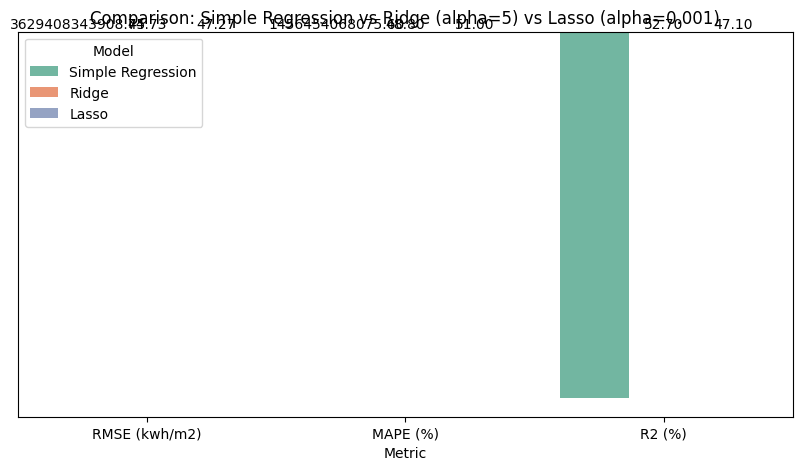

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare data for plotting
metrics = ['RMSE (kwh/m2)', 'MAPE (%)', 'R2 (%)']
rsimple_values = [rsimple_metrics[0], rsimple_metrics[1] * 100, rsimple_metrics[2] * 100]
ridge_values = [ridge_metrics[0], ridge_metrics[1] * 100, ridge_metrics[2] * 100]
lasso_values = [lasso_metrics[0], lasso_metrics[1] * 100, lasso_metrics[2] * 100]

data = pd.DataFrame({
    'Metric': metrics * 3,
    'Value': rsimple_values + ridge_values + lasso_values,
    'Model': ['Simple Regression'] * 3 + ['Ridge'] * 3 + ['Lasso'] * 3
})

# Create the bar plot
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=data, x='Metric', y='Value', hue='Model', palette='Set2')

# Add values on top of the bars
for p in ax.patches:
    if p.get_height() > 0:  # Avoid annotating bars with zero height
        ax.annotate(f'{p.get_height():.2f}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', fontsize=10)

# Remove the y-axis
ax.yaxis.set_visible(False)

plt.title('Comparison: Simple Regression vs Ridge (alpha=5) vs Lasso (alpha=0.001)')
plt.xlabel('Metric')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('../ressources/models_fitted/regressions_comparaison.png', dpi=300, bbox_inches='tight')
plt.show()

In [15]:
import warnings
warnings.filterwarnings('ignore')

In [17]:
alphas = np.linspace(0.001, 2, 10)
rmse_scores = []
mape_scores = []
r2_scores = []

for alpha in alphas:
    ridge = make_model_with_scaler_and_one_hot_encoder(model = Ridge(alpha=alpha), cols_to_scale=to_scale, cols_to_encode=to_onehot_encode)
    ridge.fit(X_train, y_train)
    y_pred = ridge.predict(X_test)
    rmse_scores.append(round(np.sqrt(mean_squared_error(y_test, y_pred)), 3))
    mape_scores.append(round(mean_absolute_percentage_error(y_test, y_pred), 3))
    r2_scores.append(round(r2_score(y_test, y_pred), 3))

# Plotting the scores
fig, axes = plt.subplots(1, 3, figsize=(30, 8))

axes[0].plot(alphas, rmse_scores, marker='o', label='RMSE')
axes[0].set_title('RMSE - Alpha')
axes[0].set_xlabel('Alpha')
axes[0].set_ylabel('RMSE')
axes[0].grid()
axes[0].legend()

axes[1].plot(alphas, mape_scores, marker='o', label='MAPE', color='orange')
axes[1].set_title('MAPE - Alpha')
axes[1].set_xlabel('Alpha')
axes[1].set_ylabel('MAPE')
axes[1].grid()
axes[1].legend()

axes[2].plot(alphas, r2_scores, marker='o', label='R2', color='green')
axes[2].set_title('R2 - Alpha')
axes[2].set_xlabel('Alpha')
axes[2].set_ylabel('R2')
axes[2].grid()
axes[2].legend()

plt.tight_layout()
plt.show()

KeyboardInterrupt: 

*Abandon des modèles de regression : pipeline encoder one hot (52% de r2 au mieux) sinon 40% avec count encoder, et 40 envions aussi sans re encodage. partout, j'ai mis le standard scaler sur les numériques.*

In [ ]:
model = make_model_with_scaler_and_one_hot_encoder(Ridge(alpha=5), to_scale, to_onehot_encode)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
ridge_metrics = round(rmse, 3), round(mape, 3), round(r2, 3)
print("Ridge - RMSE:", ridge_metrics[0], "MAPE:", ridge_metrics[1], "R2:", ridge_metrics[2]) 

Ridge - RMSE: 44.728 MAPE: 0.488 R2: 0.527


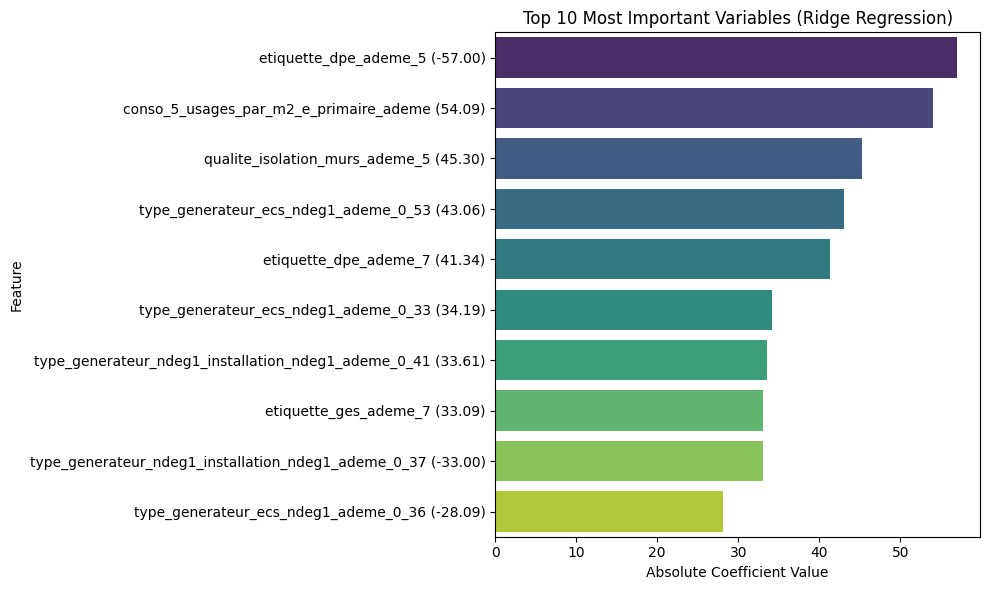

In [ ]:
# Extract feature names and coefficients
feature_names = model.named_steps['re_encoding'].get_feature_names_out()
coefficients = model.named_steps['model'].coef_

# Add sign indicator to feature names
feature_names_with_sign = [
    f"{feature} (-)" if coef < 0 else f"{feature} (+)"
    for feature, coef in zip(feature_names, coefficients)
]

feature_names_with_coef = [
    f"{feature} ({coef:.2f})" 
    for feature, coef in zip(feature_names, coefficients)
]

# Create a DataFrame for coefficients
coef_df = pd.DataFrame({'Feature': feature_names_with_coef, 'Coefficient': coefficients})
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()

# Sort by absolute coefficient values
coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False)

# Plot the top 10 most important variables
plt.figure(figsize=(10, 6))
sns.barplot(data=coef_df.head(10), x='Abs_Coefficient', y='Feature', palette='viridis')
plt.title('Top 10 Most Important Variables (Ridge Regression)')
plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()